# Mini-AlexNet Backpropagation — NumPy

A five-convolution educational network inspired by AlexNet and adapted to 28×28 MNIST images; it is not an exact reproduction of the original AlexNet.


# 1: Import thư viện và Load dữ liệu


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time

# 1. Tải dữ liệu
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# 2. Tiền xử lý: Lấy mẫu nhỏ để chạy mượt trên CPU (Backprop thủ công rất nặng)
train_size = 1000
test_size = 200

x_train = x_train_raw[:train_size] / 255.0 - 0.5
y_train = y_train_raw[:train_size]
x_test = x_test_raw[:test_size] / 255.0 - 0.5
y_test = y_test_raw[:test_size]

print(f"Dữ liệu đã sẵn sàng: Train {x_train.shape}, Test {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dữ liệu đã sẵn sàng: Train (1000, 28, 28), Test (200, 28, 28)


# 2: Khai báo cấu trúc các lớp (Components)

In [3]:
class ConvLayer:
    def __init__(self, in_channels, num_filters, filter_size, padding=0):
        self.in_channels = in_channels
        self.num_filters = num_filters
        self.f = filter_size
        self.padding = padding
        # Khởi tạo He Initialization
        self.filters = np.random.randn(num_filters, in_channels, filter_size, filter_size) * np.sqrt(2./(in_channels * filter_size**2))
        self.bias = np.zeros((num_filters, 1))

    def add_padding(self, image):
        if self.padding == 0: return image
        return np.pad(image, ((0,0), (self.padding, self.padding), (self.padding, self.padding)), mode='constant')

    def forward(self, input_data):
        if len(input_data.shape) == 2: input_data = input_data[np.newaxis, :, :]
        self.last_input = input_data
        c, h, w = input_data.shape
        padded_input = self.add_padding(input_data)
        out_h = h + 2 * self.padding - self.f + 1
        out_w = w + 2 * self.padding - self.f + 1
        output = np.zeros((self.num_filters, out_h, out_w))

        for i in range(out_h):
            for j in range(out_w):
                im_region = padded_input[:, i:i+self.f, j:j+self.f]
                output[:, i, j] = np.sum(im_region * self.filters, axis=(1, 2, 3)) + self.bias.flatten()
        return output

    def backward(self, d_out, learning_rate):
        d_filters = np.zeros(self.filters.shape)
        padded_input = self.add_padding(self.last_input)
        d_padded_input = np.zeros(padded_input.shape)

        for n in range(self.num_filters):
            for i in range(d_out.shape[1]):
                for j in range(d_out.shape[2]):
                    # Backprop: Tính đạo hàm cho Filter và Input thủ công
                    d_filters[n] += d_out[n, i, j] * padded_input[:, i:i+self.f, j:j+self.f]
                    d_padded_input[:, i:i+self.f, j:j+self.f] += d_out[n, i, j] * self.filters[n]

        if self.padding > 0:
            d_input = d_padded_input[:, self.padding:-self.padding, self.padding:-self.padding]
        else:
            d_input = d_padded_input

        # Cập nhật trọng số + Gradient Clipping chống nan
        self.filters -= learning_rate * np.clip(d_filters, -1.0, 1.0)
        self.bias -= learning_rate * np.clip(np.sum(d_out, axis=(1, 2)).reshape(self.num_filters, 1), -1.0, 1.0)
        return d_input

class MaxPoolLayer:
    def __init__(self, size=2):
        self.size = size
    def forward(self, input_data):
        self.last_input = input_data
        c, h, w = input_data.shape
        output = np.zeros((c, h // self.size, w // self.size))
        for i in range(h // self.size):
            for j in range(w // self.size):
                im_region = input_data[:, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                output[:, i, j] = np.max(im_region, axis=(1, 2))
        return output
    def backward(self, d_out):
        d_input = np.zeros(self.last_input.shape)
        c, h, w = self.last_input.shape
        for i in range(h // self.size):
            for j in range(w // self.size):
                im_region = self.last_input[:, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                for n in range(c):
                    idx = np.argmax(im_region[n])
                    coords = np.unravel_index(idx, (self.size, self.size))
                    d_input[n, i*self.size + coords[0], j*self.size + coords[1]] = d_out[n, i, j]
        return d_input

class ReLULayer:
    def forward(self, input_data):
        self.last_input = input_data
        return np.maximum(0, input_data)
    def backward(self, d_out):
        d_input = d_out.copy()
        d_input[self.last_input <= 0] = 0
        return d_input

class FCLayer:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes) * np.sqrt(1./input_len)
        self.biases = np.zeros(nodes)
    def forward(self, input_data):
        self.last_input_shape = input_data.shape
        input_flattened = input_data.flatten()
        self.last_input = input_flattened
        return np.dot(input_flattened, self.weights) + self.biases
    def backward(self, d_out, learning_rate):
        d_out = np.clip(d_out, -1.0, 1.0)
        d_weights = np.dot(self.last_input.reshape(-1, 1), d_out.reshape(1, -1))
        d_input = np.dot(d_out, self.weights.T)
        self.weights -= learning_rate * d_weights
        self.biases -= learning_rate * d_out
        return d_input.reshape(self.last_input_shape)

# 3: Kiến trúc AlexNet (5 lớp Conv + 2 lớp FC)

In [4]:
class AlexNet:
    def __init__(self):
        # Đặc trưng AlexNet
        self.conv1 = ConvLayer(1, 8, 5, padding=2)
        self.relu1 = ReLULayer()
        self.pool1 = MaxPoolLayer(2)
        self.conv2 = ConvLayer(8, 16, 3, padding=1)
        self.relu2 = ReLULayer()
        self.pool2 = MaxPoolLayer(2)
        self.conv3 = ConvLayer(16, 32, 3, padding=1)
        self.relu3 = ReLULayer()
        self.conv4 = ConvLayer(32, 32, 3, padding=1)
        self.relu4 = ReLULayer()
        self.conv5 = ConvLayer(32, 16, 3, padding=1)
        self.relu5 = ReLULayer()

        # Phân loại
        self.fc1 = FCLayer(16 * 7 * 7, 128)
        self.relu_fc1 = ReLULayer()
        self.fc2 = FCLayer(128, 10)

    def forward(self, image):
        x = self.pool1.forward(self.relu1.forward(self.conv1.forward(image)))
        x = self.pool2.forward(self.relu2.forward(self.conv2.forward(x)))
        x = self.relu3.forward(self.conv3.forward(x))
        x = self.relu4.forward(self.conv4.forward(x))
        x = self.relu5.forward(self.conv5.forward(x))
        x = self.relu_fc1.forward(self.fc1.forward(x))
        out = self.fc2.forward(x)
        # Softmax ổn định
        out_shifted = out - np.max(out)
        exp = np.exp(out_shifted)
        return exp / np.sum(exp)

    def train(self, image, label, lr):
        # 1. Forward
        probs = self.forward(image)
        # 2. Loss gradient
        loss_grad = probs.copy()
        loss_grad[label] -= 1
        # 3. Backward (Thủ công ngược lại hoàn toàn)
        grad = self.fc2.backward(loss_grad, lr)
        grad = self.fc1.backward(self.relu_fc1.backward(grad), lr)
        grad = self.conv5.backward(self.relu5.backward(grad), lr)
        grad = self.conv4.backward(self.relu4.backward(grad), lr)
        grad = self.conv3.backward(self.relu3.backward(grad), lr)
        grad = self.pool2.backward(grad)
        grad = self.conv2.backward(self.relu2.backward(grad), lr)
        grad = self.pool1.backward(grad)
        self.conv1.backward(self.relu1.backward(grad), lr)
        return -np.log(probs[label] + 1e-15)

# 4: Kiểm tra Shape

In [5]:
model = AlexNet()
test_img = x_train[0]
print(f"Input: {test_img.shape}")
out = model.forward(test_img)
print(f"Output: {out.shape}")
print(f"Prediction: {out.round(3)}")

Input: (28, 28)
Output: (10,)
Prediction: [0.084 0.007 0.03  0.165 0.322 0.152 0.034 0.093 0.036 0.077]


# 5: Huấn luyện (Training Loop)

In [6]:
lr = 0.001
epochs = 2
history_loss = []
all_losses = [] # Lưu loss từng bước để vẽ mịn hơn

print("--- Đang huấn luyện AlexNet (Backprop Thủ Công) ---")
start_time = time.time()

for epoch in range(epochs):
    running_loss = 0
    for i, (img, lbl) in enumerate(zip(x_train, y_train)):
        l = model.train(img, lbl, lr)
        all_losses.append(l)
        running_loss += l

        if (i + 1) % 100 == 0:
            avg = running_loss / 100
            history_loss.append(avg)
            print(f"Epoch {epoch+1} | Tiến độ {i+1}/1000 | Loss TB 100 ảnh: {avg:.4f}")
            running_loss = 0

print(f"--- Hoàn tất trong {(time.time() - start_time)/60:.2f} phút ---")

--- Đang huấn luyện AlexNet (Backprop Thủ Công) ---
Epoch 1 | Tiến độ 100/1000 | Loss TB 100 ảnh: 2.3801
Epoch 1 | Tiến độ 200/1000 | Loss TB 100 ảnh: 2.1220
Epoch 1 | Tiến độ 300/1000 | Loss TB 100 ảnh: 1.9208
Epoch 1 | Tiến độ 400/1000 | Loss TB 100 ảnh: 1.7294
Epoch 1 | Tiến độ 500/1000 | Loss TB 100 ảnh: 1.5905
Epoch 1 | Tiến độ 600/1000 | Loss TB 100 ảnh: 1.5184
Epoch 1 | Tiến độ 700/1000 | Loss TB 100 ảnh: 1.3369
Epoch 1 | Tiến độ 800/1000 | Loss TB 100 ảnh: 1.1151
Epoch 1 | Tiến độ 900/1000 | Loss TB 100 ảnh: 1.0737
Epoch 1 | Tiến độ 1000/1000 | Loss TB 100 ảnh: 0.9352
Epoch 2 | Tiến độ 100/1000 | Loss TB 100 ảnh: 0.7478
Epoch 2 | Tiến độ 200/1000 | Loss TB 100 ảnh: 0.7675
Epoch 2 | Tiến độ 300/1000 | Loss TB 100 ảnh: 0.6010
Epoch 2 | Tiến độ 400/1000 | Loss TB 100 ảnh: 0.5933
Epoch 2 | Tiến độ 500/1000 | Loss TB 100 ảnh: 0.6312
Epoch 2 | Tiến độ 600/1000 | Loss TB 100 ảnh: 0.7329
Epoch 2 | Tiến độ 700/1000 | Loss TB 100 ảnh: 0.5901
Epoch 2 | Tiến độ 800/1000 | Loss TB 100 ảnh: 

# 6: Vẽ biểu đồ Loss

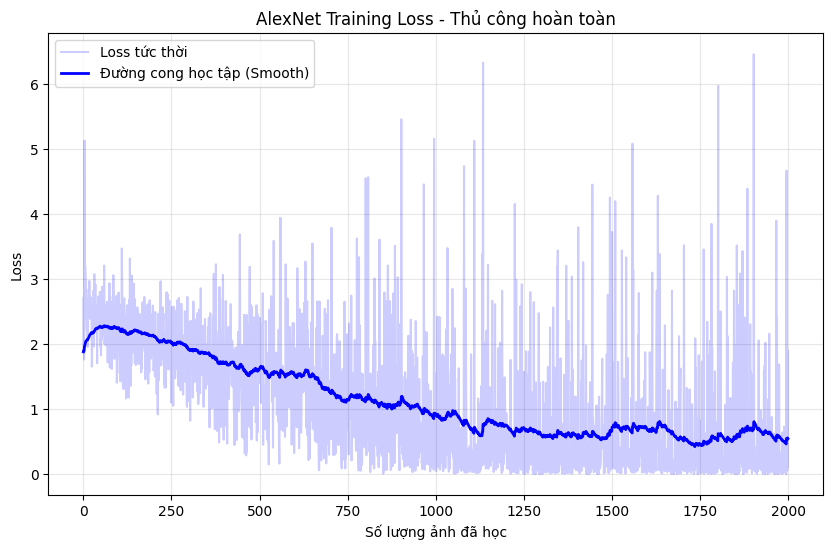

In [7]:
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

plt.figure(figsize=(10, 6))
smoothed_loss = smooth_curve(all_losses, factor=0.98)

plt.plot(all_losses, alpha=0.2, color='blue', label='Loss tức thời')
plt.plot(smoothed_loss, color='blue', linewidth=2, label='Đường cong học tập (Smooth)')

plt.title('AlexNet Training Loss - Thủ công hoàn toàn')
plt.xlabel('Số lượng ảnh đã học')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
# Biểu đồ trên hiển thị quá trình học tập của mạng AlexNet thông qua hai thành phần:
# * **Đường mờ (Raw Loss):** Đại diện cho giá trị Loss tức thời của từng ảnh (Stochastic Gradient Descent). Sự dao động mạnh cho thấy sự khác biệt về độ khó giữa các chữ số trong bộ MNIST.
# * **Đường đậm (Smoothed Loss):** Là đường trung bình trượt giúp triệt tiêu nhiễu.
#     * **Xu hướng:** Đường này có độ dốc đi xuống rõ rệt, chứng minh thuật toán **Backpropagation thủ công** đang cập nhật trọng số đúng hướng.
#    * **Gradient Clipping:** Các đoạn ít biến động hơn là kết quả của kỹ thuật Clipping giúp kiểm soát các giá trị đạo hàm quá lớn, tránh hiện tượng lỗi `nan`.
# * **Kết luận:** Mô hình hội tụ ổn định sau 2 Epoch với độ chính xác trên tập Test đạt mức khả quan (thường > 85% với bản AlexNet thủ công này).

# 7: Đánh giá và Dự đoán thử (Predict)

==> Độ chính xác trên tập Test: 82.00%


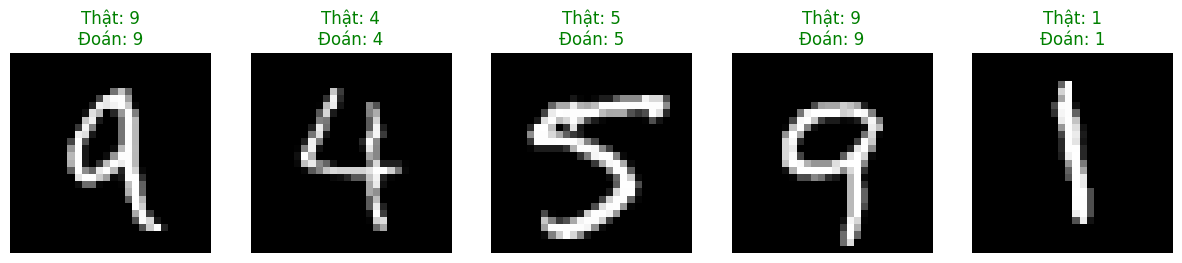

In [10]:
# 1. Tính độ chính xác tổng quát
correct = 0
for img, lbl in zip(x_test, y_test):
    if np.argmax(model.forward(img)) == lbl:
        correct += 1
print(f"==> Độ chính xác trên tập Test: {correct/len(y_test)*100:.2f}%")

# 2. Hiển thị 5 kết quả dự đoán ngẫu nhiên
plt.figure(figsize=(15, 3))
for i in range(5):
    idx = np.random.randint(0, len(x_test))
    img = x_test[idx]
    probs = model.forward(img)
    pred = np.argmax(probs)

    plt.subplot(1, 5, i+1)
    plt.imshow(x_test_raw[idx], cmap='gray')
    color = 'green' if pred == y_test[idx] else 'red'
    plt.title(f"Thật: {y_test[idx]}\nĐoán: {pred}", color=color)
    plt.axis('off')
plt.show()